In [7]:
# Load data from CSV into DataFrame
import pandas as pd

# Load CSV file into DataFrame
df = pd.read_csv('../files/ragas_eval_result.csv')

# Display basic information about the DataFrame
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Display first few rows
df.head()

DataFrame shape: (246, 6)
Columns: ['question', 'recontext_relevance', 'context_precision', 'answer_relevancy', 'semantic_similarity', 'llm']


,question,recontext_relevance,context_precision,answer_relevancy,semantic_similarity,llm
0,What is the main focus of the document?,1.0,1.0,0.00000,0.712563,Deepseek
1,What are Scott Logic's greenhouse gas reductio...,1.0,1.0,0.00000,0.806831,Deepseek
2,What is the potential concern regarding the Pl...,1.0,1.0,0.99368,0.839723,Deepseek
3,What are Scott Logic's renewable energy goals?,1.0,1.0,0.00000,0.790629,Deepseek
4,What is the company's approach to water usage ...,0.5,1.0,0.00000,0.757941,Deepseek


In [8]:
# Tidy data

# Remove rows with 'AVERAGE' question value or empty question values
print(f"Original DataFrame shape: {df.shape}")

# Remove rows where question is 'AVERAGE' or empty/null
df_clean = df[
    (df['question'] != 'AVERAGE') & 
    (df['question'].notna()) & 
    (df['question'] != '') & 
    (df['question'].str.strip() != '')
].copy()

print(f"Cleaned DataFrame shape: {df_clean.shape}")
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows")

# Update df to use the cleaned version
df = df_clean

# Display first few rows of cleaned data
df.head()

Original DataFrame shape: (246, 6)
Cleaned DataFrame shape: (238, 6)
Removed 8 rows


,question,recontext_relevance,context_precision,answer_relevancy,semantic_similarity,llm
0,What is the main focus of the document?,1.0,1.0,0.00000,0.712563,Deepseek
1,What are Scott Logic's greenhouse gas reductio...,1.0,1.0,0.00000,0.806831,Deepseek
2,What is the potential concern regarding the Pl...,1.0,1.0,0.99368,0.839723,Deepseek
3,What are Scott Logic's renewable energy goals?,1.0,1.0,0.00000,0.790629,Deepseek
4,What is the company's approach to water usage ...,0.5,1.0,0.00000,0.757941,Deepseek


In [9]:
# Calculate and display average values for each LLM
print("Average Semantic Similarity Scores by LLM:")
print("=" * 45)

# Calculate averages for semantic_similarity by LLM
llm_averages = df.groupby('llm')['semantic_similarity'].mean().sort_values(ascending=False)

for llm, avg_score in llm_averages.items():
    print(f"{llm}: {avg_score:.4f}")

print("\nAll Metrics Averages by LLM:")
print("=" * 35)

# Calculate averages for all numeric columns by LLM
numeric_columns = df.select_dtypes(include=['number']).columns
llm_all_averages = df.groupby('llm')[numeric_columns].mean()

# Display in a formatted table
print(llm_all_averages.round(4))

Average Semantic Similarity Scores by LLM:
openai-4o: 0.8693
oss: 0.8504
Gemma: 0.8498
qwen3: 0.8368
lfm1.2b: 0.7907
Deepseek: 0.7663

All Metrics Averages by LLM:
           recontext_relevance  context_precision  answer_relevancy  \
llm                                                                   
Deepseek                0.8611             0.9556            0.1468   
Gemma                   0.9310             1.0000            0.7463   
lfm1.2b                 0.8833             0.9556            0.3961   
openai-4o               0.8556             0.9556            0.7482   
oss                     0.9138             0.9655            0.3680   
qwen3                   0.8889             0.9556            0.7497   

           semantic_similarity  
llm                             
Deepseek                0.7663  
Gemma                   0.8498  
lfm1.2b                 0.7907  
openai-4o               0.8693  
oss                     0.8504  
qwen3                   0.8368  


<Figure size 1200x600 with 0 Axes>

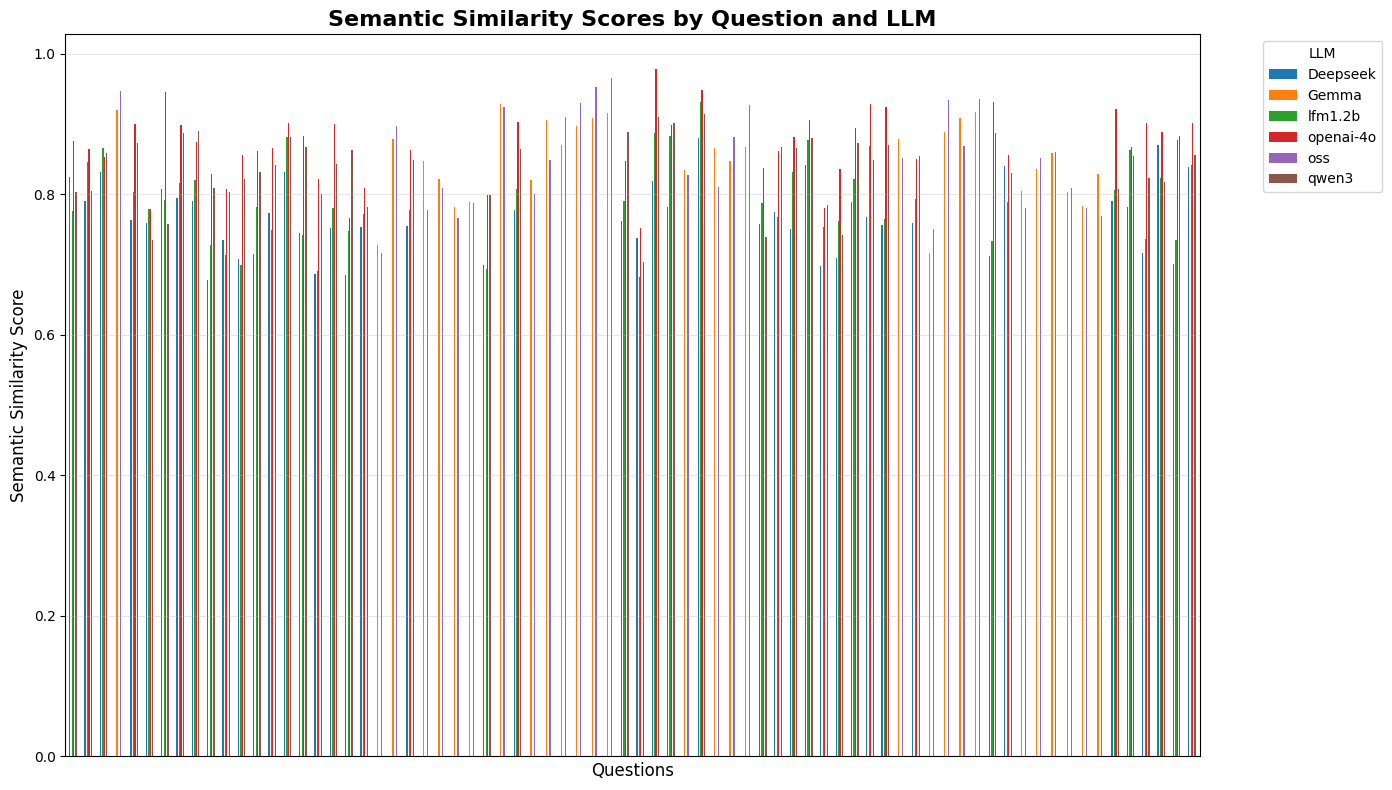

In [10]:
# Create visualizations using matplotlib and seaborn
import matplotlib.pyplot as plt
# import seaborn as sns

# Set up the plot style
plt.style.use('default')
#sns.set_palette("husl")

# Create column chart for semantic_similarity by question, grouped by LLM
plt.figure(figsize=(12, 6))

# Group by question and LLM, then plot
pivot_data = df.pivot(index='question', columns='llm', values='semantic_similarity')

# Create grouped bar chart
ax = pivot_data.plot(kind='bar', figsize=(14, 8))
plt.title('Semantic Similarity Scores by Question and LLM', fontsize=16, fontweight='bold')
plt.xlabel('Questions', fontsize=12)
plt.ylabel('Semantic Similarity Score', fontsize=12)
plt.xticks([])  # Hide x-axis text labels
plt.legend(title='LLM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)


plt.show()

<Figure size 1200x600 with 0 Axes>

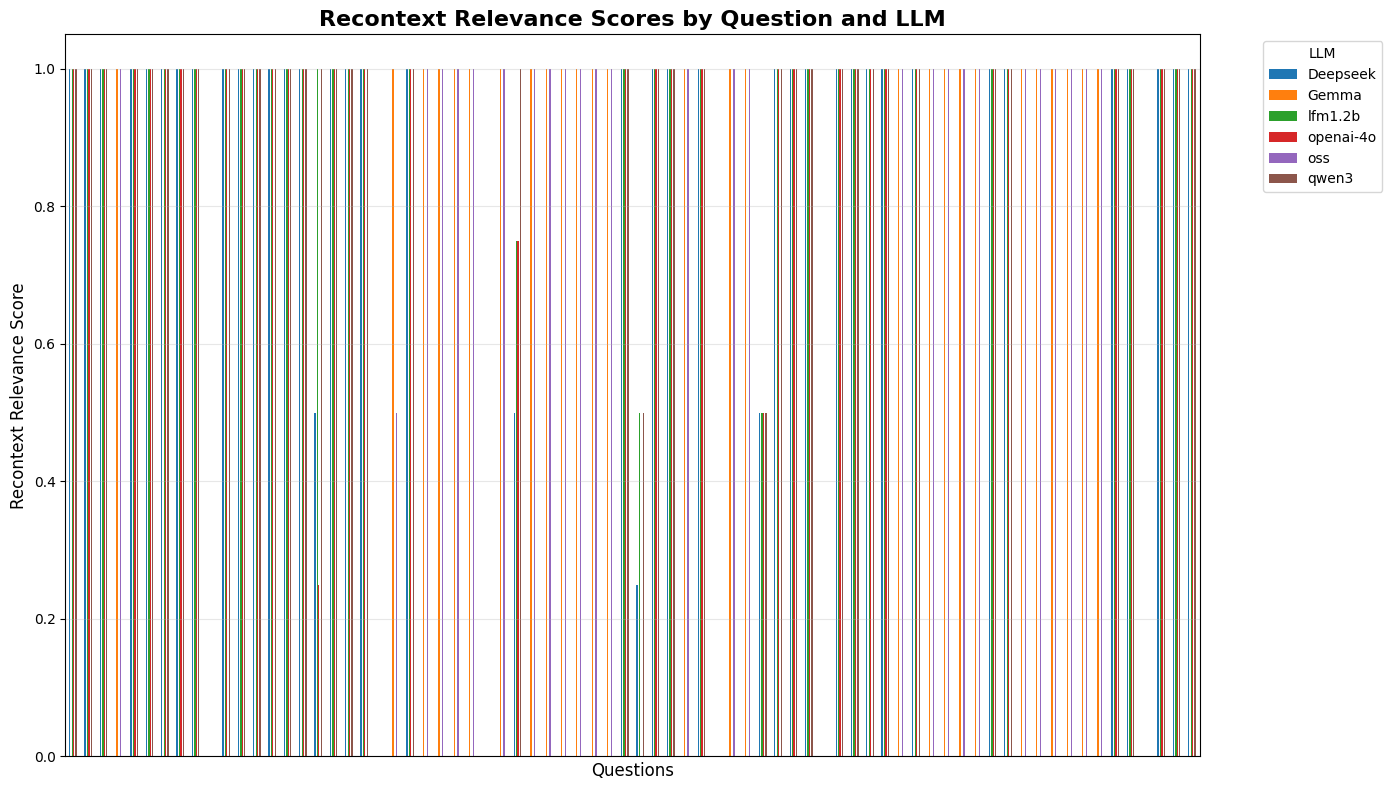

In [12]:
# Create plot for recontext_relevance
plt.figure(figsize=(12, 6))

# Group by question and LLM, then plot
pivot_data = df.pivot(index='question', columns='llm', values='recontext_relevance')

# Create grouped bar chart
ax = pivot_data.plot(kind='bar', figsize=(14, 8))
plt.title('Recontext Relevance Scores by Question and LLM', fontsize=16, fontweight='bold')
plt.xlabel('Questions', fontsize=12)
plt.ylabel('Recontext Relevance Score', fontsize=12)
plt.xticks([])  # Hide x-axis text labels
plt.legend(title='LLM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

plt.show()

<Figure size 1200x600 with 0 Axes>

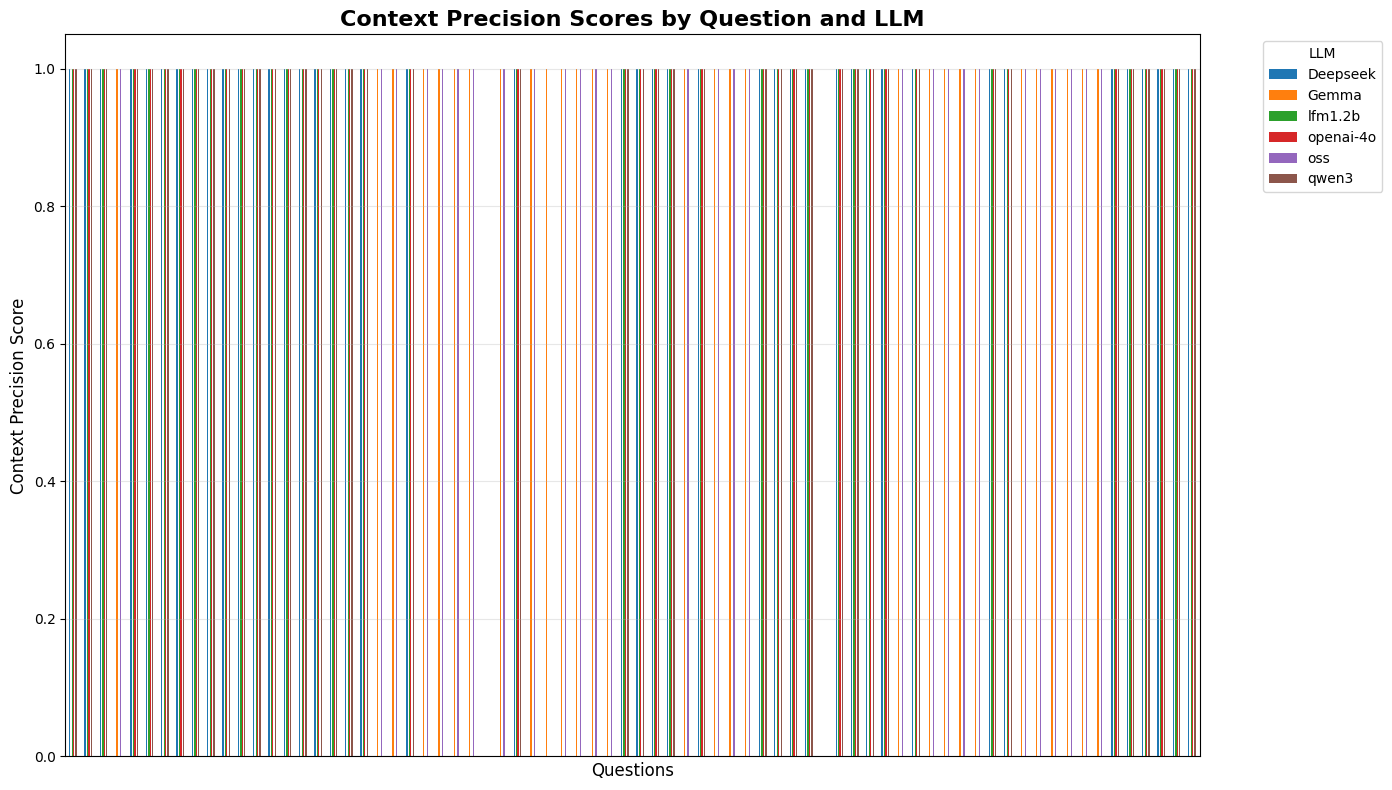

In [13]:
# Create plot for context_precision
plt.figure(figsize=(12, 6))

# Group by question and LLM, then plot
pivot_data = df.pivot(index='question', columns='llm', values='context_precision')

# Create grouped bar chart
ax = pivot_data.plot(kind='bar', figsize=(14, 8))
plt.title('Context Precision Scores by Question and LLM', fontsize=16, fontweight='bold')
plt.xlabel('Questions', fontsize=12)
plt.ylabel('Context Precision Score', fontsize=12)
plt.xticks([])  # Hide x-axis text labels
plt.legend(title='LLM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

plt.show()

<Figure size 1200x600 with 0 Axes>

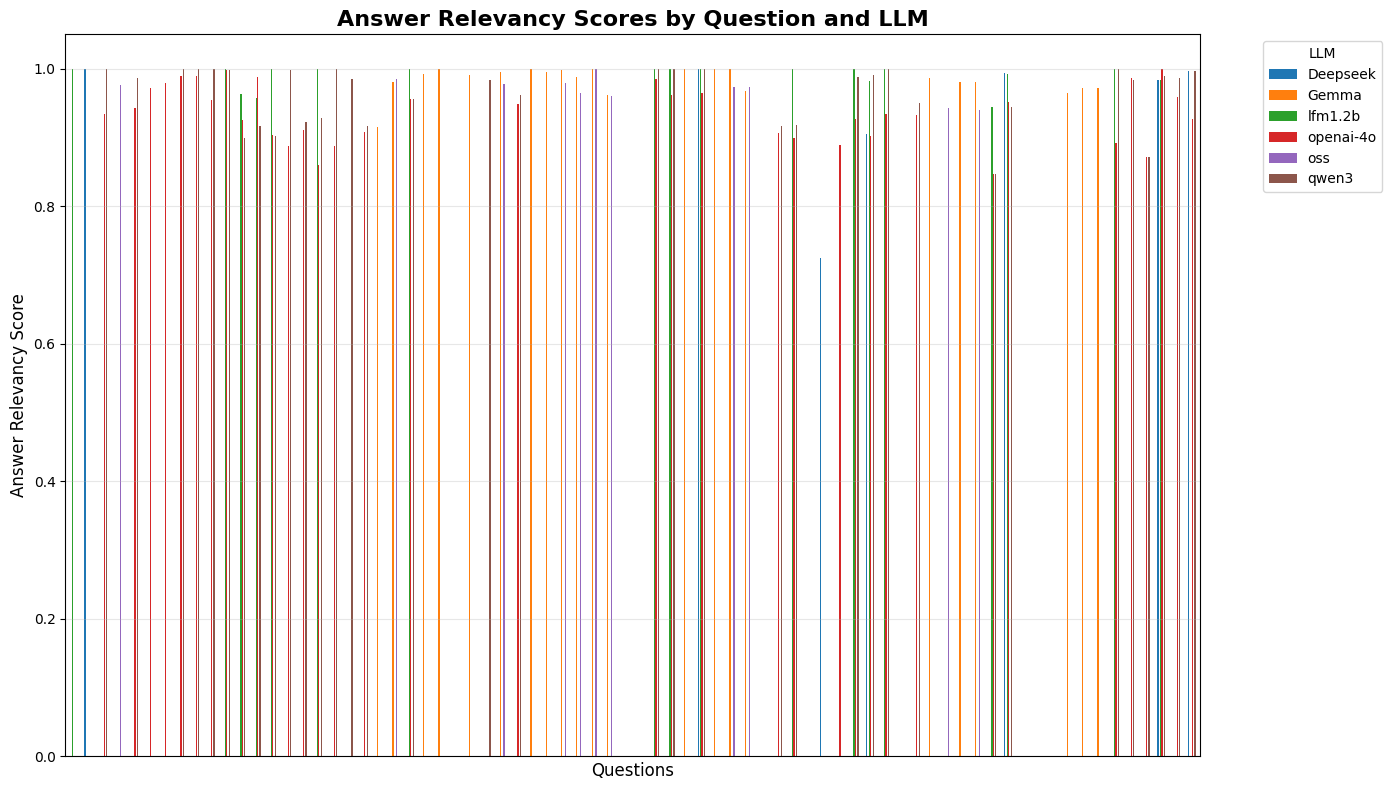

In [14]:
# Create plot for answer_relevancy
plt.figure(figsize=(12, 6))

# Group by question and LLM, then plot
pivot_data = df.pivot(index='question', columns='llm', values='answer_relevancy')

# Create grouped bar chart
ax = pivot_data.plot(kind='bar', figsize=(14, 8))
plt.title('Answer Relevancy Scores by Question and LLM', fontsize=16, fontweight='bold')
plt.xlabel('Questions', fontsize=12)
plt.ylabel('Answer Relevancy Score', fontsize=12)
plt.xticks([])  # Hide x-axis text labels
plt.legend(title='LLM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

plt.show()